In [4]:
!pip install rouge-score

In [5]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [6]:
import os
import pickle
from collections import Counter

import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

from PIL import Image
import matplotlib.pyplot as plt

from tqdm import tqdm

In [7]:
BASE = "/content/drive/MyDrive/MultiModalProject/Flickr8k"

TRAIN_CSV = os.path.join(BASE, "dataset_caption_train.csv")
VAL_CSV   = os.path.join(BASE, "dataset_caption_val.csv")
TEST_CSV  = os.path.join(BASE, "dataset_caption_test.csv")

TRAIN_FEATURES = os.path.join(BASE, "efficient_train.npy")
VAL_FEATURES   = os.path.join(BASE, "efficient_val.npy")
TEST_FEATURES  = os.path.join(BASE, "efficient_test.npy")

MODEL_DIR = os.path.join(BASE, "models", "GRU")

os.makedirs(MODEL_DIR, exist_ok=True)

In [8]:
train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(29112, 2)
(3238, 2)
(8095, 2)


In [9]:
train_features = np.load(
    TRAIN_FEATURES,
    allow_pickle=True
).item()

val_features = np.load(
    VAL_FEATURES,
    allow_pickle=True
).item()

test_features = np.load(
    TEST_FEATURES,
    allow_pickle=True
).item()

print(len(train_features))
print(len(val_features))
print(len(test_features))

5824
648
1619


In [10]:
counter = Counter()

for cap in train_df["caption"]:

    words = cap.split()

    counter.update(words)

vocab = {

    "<pad>":0,
    "<start>":1,
    "<end>":2,
    "<unk>":3

}

index = 4

for word, count in counter.items():

    if word in ["<pad>", "<start>", "<end>", "<unk>"]:
        continue

    if count >= 2:

        vocab[word] = index

        index += 1

idx2word = {
    v:k
    for k,v in vocab.items()
}

print("Vocab Size:", len(vocab))
print("Last Index:", max(vocab.values()))

Vocab Size: 4454
Last Index: 4453


In [11]:
with open(
    os.path.join(MODEL_DIR, "vocab.pkl"),
    "wb"
) as f:

    pickle.dump(vocab, f)

In [12]:
def encode_caption(caption):

    words = caption.split()

    encoded = []

    for word in words:

        encoded.append(

            vocab.get(
                word,
                vocab["<unk>"]
            )

        )

    return torch.tensor(encoded)

In [13]:
train_df["encoded"] = train_df["caption"].apply(
    encode_caption
)

val_df["encoded"] = val_df["caption"].apply(
    encode_caption
)

test_df["encoded"] = test_df["caption"].apply(
    encode_caption
)

print(train_df.iloc[0]["caption"])
print(train_df.iloc[0]["encoded"])

<start> a child in a pink dress is climbing up a set of stairs in an entry way <end>
tensor([ 1,  4,  5,  6,  4,  7,  8,  9, 10, 11,  4, 12, 13, 14,  6, 15,  3, 16,
         2])


In [14]:
class CaptionDataset(Dataset):

    def __init__(
        self,
        dataframe,
        feature_dict
    ):

        self.df = dataframe.reset_index(
            drop=True
        )

        self.features = feature_dict

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image = row["image"]

        feature = torch.tensor(

            self.features[image]

        ).float()

        caption = row["encoded"]

        return feature, caption

In [15]:
def collate_fn(batch):

    images = []

    captions = []

    for img, cap in batch:

        images.append(img)

        captions.append(cap)

    images = torch.stack(images)

    captions = pad_sequence(

        captions,

        batch_first=True,

        padding_value=vocab["<pad>"]

    )

    return images, captions


train_loader = DataLoader(

    CaptionDataset(
        train_df,
        train_features
    ),

    batch_size=32,

    shuffle=True,

    collate_fn=collate_fn

)

val_loader = DataLoader(

    CaptionDataset(
        val_df,
        val_features
    ),

    batch_size=32,

    shuffle=False,

    collate_fn=collate_fn

)

test_loader = DataLoader(

    CaptionDataset(
        test_df,
        test_features
    ),

    batch_size=32,

    shuffle=False,

    collate_fn=collate_fn

)

images, captions = next(
    iter(train_loader)
)

print(images.shape)
print(captions.shape)

torch.Size([32, 49, 1280])
torch.Size([32, 31])


In [16]:
class BahdanauAttention(nn.Module):

    def __init__(
        self,
        encoder_dim,
        decoder_dim,
        attention_dim
    ):

        super().__init__()

        self.encoder_att = nn.Linear(
            encoder_dim,
            attention_dim
        )

        self.decoder_att = nn.Linear(
            decoder_dim,
            attention_dim
        )

        self.full_att = nn.Linear(
            attention_dim,
            1
        )

        self.relu = nn.ReLU()

        self.softmax = nn.Softmax(dim=1)

    def forward(
        self,
        encoder_out,
        decoder_hidden
    ):

        att1 = self.encoder_att(
            encoder_out
        )

        att2 = self.decoder_att(
            decoder_hidden
        ).unsqueeze(1)

        energy = self.full_att(

            self.relu(
                att1 + att2
            )

        ).squeeze(2)

        alpha = self.softmax(
            energy
        )

        context = (

            encoder_out *
            alpha.unsqueeze(2)

        ).sum(dim=1)

        return context, alpha

In [17]:
class AttentionGRU(nn.Module):

    def __init__(
        self,
        vocab_size,
        encoder_dim=1280,
        embed_dim=256,
        decoder_dim=512,
        attention_dim=512,
        dropout=0.5
    ):

        super().__init__()

        self.decoder_dim = decoder_dim

        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=0
        )

        self.attention = BahdanauAttention(
            encoder_dim,
            decoder_dim,
            attention_dim
        )

        self.gru = nn.GRUCell(
            embed_dim + encoder_dim,
            decoder_dim
        )

        self.dropout = nn.Dropout(
            dropout
        )

        self.fc = nn.Linear(
            decoder_dim,
            vocab_size
        )

    def forward(
        self,
        features,
        captions
    ):

        batch_size = features.size(0)

        seq_len = captions.size(1)

        embeddings = self.embedding(
            captions
        )

        h = torch.zeros(

            batch_size,
            self.decoder_dim,

            device=features.device

        )

        outputs = []

        for t in range(seq_len - 1):

            context, alpha = self.attention(

                features,
                h

            )

            gru_input = torch.cat(

                (

                    embeddings[:, t, :],
                    context

                ),

                dim=1

            )

            h = self.gru(

                gru_input,
                h

            )

            out = self.fc(

                self.dropout(h)

            )

            outputs.append(out)

        outputs = torch.stack(

            outputs,

            dim=1

        )

        return outputs

In [18]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

model = AttentionGRU(

    vocab_size=len(vocab)

).to(device)

criterion = nn.CrossEntropyLoss(

    ignore_index=vocab["<pad>"]

)

optimizer = torch.optim.Adam(

    model.parameters(),

    lr=1e-3

)

print(device)

cpu


In [19]:
images, captions = next(
    iter(train_loader)
)

images = images.to(device)

captions = captions.to(device)

outputs = model(

    images,
    captions

)

print(images.shape)
print(captions.shape)
print(outputs.shape)

torch.Size([32, 49, 1280])
torch.Size([32, 19])
torch.Size([32, 18, 4454])


In [20]:
def train_one_epoch(

    model,
    loader,
    optimizer,
    criterion,
    device

):

    model.train()

    total_loss = 0

    for images, captions in loader:

        images = images.to(device)

        captions = captions.to(device)

        optimizer.zero_grad()

        outputs = model(

            images,
            captions

        )

        loss = criterion(

            outputs.reshape(

                -1,
                outputs.size(-1)

            ),

            captions[:,1:].reshape(-1)

        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(

            model.parameters(),

            max_norm=5

        )

        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [21]:
def validate(

    model,
    loader,
    criterion,
    device

):

    model.eval()

    total_loss = 0

    with torch.no_grad():

        for images, captions in loader:

            images = images.to(device)

            captions = captions.to(device)

            outputs = model(

                images,
                captions

            )

            loss = criterion(

                outputs.reshape(

                    -1,
                    outputs.size(-1)

                ),

                captions[:,1:].reshape(-1)

            )

            total_loss += loss.item()

    return total_loss / len(loader)

In [22]:
best_loss = float("inf")

counter = 0

patience = 5

num_epochs = 30

for epoch in range(num_epochs):

    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device
    )

    val_loss = validate(
        model,
        val_loader,
        criterion,
        device
    )

    print(
        f"Epoch {epoch+1:02d}"
        f" | Train {train_loss:.4f}"
        f" | Val {val_loss:.4f}"
    )

    if val_loss < best_loss:

        best_loss = val_loss

        counter = 0

        torch.save(

            model.state_dict(),

            os.path.join(

                MODEL_DIR,

                "gru_caption_model.pth"

            )

        )

        print("✅ Best model saved")

    else:

        counter += 1

        print(
            f"Patience {counter}/{patience}"
        )

        if counter >= patience:

            print("🛑 Early stopping")

            break

Epoch 01 | Train 3.6542 | Val 3.0654
✅ Best model saved
Epoch 02 | Train 2.9267 | Val 2.9045
✅ Best model saved
Epoch 03 | Train 2.6208 | Val 2.8545
✅ Best model saved
Epoch 04 | Train 2.4018 | Val 2.8627
Patience 1/5
Epoch 05 | Train 2.2254 | Val 2.8824
Patience 2/5
Epoch 06 | Train 2.0817 | Val 2.9065
Patience 3/5
Epoch 07 | Train 1.9624 | Val 2.9504
Patience 4/5
Epoch 08 | Train 1.8582 | Val 3.0067
Patience 5/5
🛑 Early stopping


In [23]:
model = AttentionGRU(

    vocab_size=len(vocab)

).to(device)

model.load_state_dict(

    torch.load(

        os.path.join(

            MODEL_DIR,

            "gru_caption_model.pth"

        ),

        map_location=device

    )

)

model.eval()

print("✅ Best GRU loaded")

✅ Best GRU loaded


In [24]:
def generate_caption(

    model,

    feature,

    vocab,

    idx2word,

    max_len=25

):

    model.eval()

    with torch.no_grad():

        feature = feature.to(device)

        h = torch.zeros(

            1,

            model.decoder_dim,

            device=device

        )

        outputs = []

        word = torch.tensor(

            [[vocab["<start>"]]],

            device=device

        )

        for _ in range(max_len):

            embedding = model.embedding(word).squeeze(1)

            context, _ = model.attention(

                feature,

                h

            )

            gru_input = torch.cat(

                (

                    embedding,

                    context

                ),

                dim=1

            )

            h = model.gru(

                gru_input,

                h

            )

            out = model.fc(

                h

            )

            pred = out.argmax(1).item()

            if pred == vocab["<end>"]:
                break

            word_text = idx2word.get(pred, "<unk>")

            if word_text not in ["<start>", "<pad>"]:

                outputs.append(word_text)

            word = torch.tensor(

                [[pred]],

                device=device

            )

    return " ".join(outputs)

REAL:

a boy with a toy gun

PRED:

a young boy wearing a blue shirt is playing with a toy


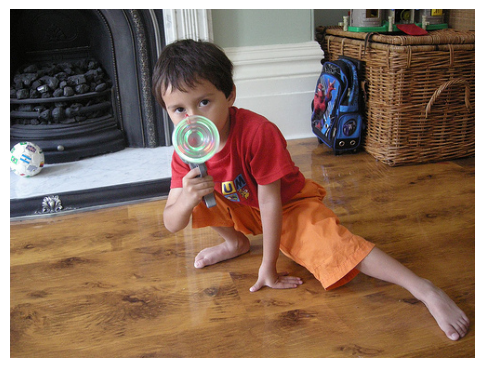

In [25]:
idx = 100

row = test_df.iloc[idx]

feature = torch.tensor(

    test_features[row["image"]],

    dtype=torch.float32

).unsqueeze(0).to(device)

pred = generate_caption(

    model,

    feature,

    vocab,

    idx2word

)

print("REAL:\n")

print(

    row["caption"]

    .replace("<start>", "")

    .replace("<end>", "")

    .strip()

)

print("\nPRED:\n")

print(pred)

img = Image.open(

    os.path.join(

        BASE,

        "Images",

        row["image"]

    )

)

plt.figure(figsize=(6,6))

plt.imshow(img)

plt.axis("off")

plt.show()

In [27]:
import nltk

nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [28]:
from nltk.translate.bleu_score import corpus_bleu
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer
from tqdm import tqdm

references = []
hypotheses = []

meteor_scores = []

rouge = rouge_scorer.RougeScorer(
    ["rougeL"],
    use_stemmer=True
)

rouge_scores = []

model.eval()

for _, row in tqdm(test_df.iterrows(), total=len(test_df)):

    feature = torch.tensor(
        test_features[row["image"]],
        dtype=torch.float32
    ).unsqueeze(0).to(device)

    pred = generate_caption(
        model,
        feature,
        vocab,
        idx2word
    )

    pred_words = pred.split()

    gt = (
        row["caption"]
        .replace("<start>", "")
        .replace("<end>", "")
        .strip()
    )

    gt_words = gt.split()

    references.append([gt_words])
    hypotheses.append(pred_words)

    meteor_scores.append(

        meteor_score(
            [gt_words],
            pred_words
        )

    )

    rouge_scores.append(

        rouge.score(
            gt,
            pred
        )["rougeL"].fmeasure

    )

bleu1 = corpus_bleu(
    references,
    hypotheses,
    weights=(1,0,0,0)
)

bleu2 = corpus_bleu(
    references,
    hypotheses,
    weights=(0.5,0.5,0,0)
)

bleu3 = corpus_bleu(
    references,
    hypotheses,
    weights=(0.33,0.33,0.33,0)
)

bleu4 = corpus_bleu(
    references,
    hypotheses,
    weights=(0.25,0.25,0.25,0.25)
)

print("="*40)

print(f"BLEU-1  : {bleu1:.4f}")
print(f"BLEU-2  : {bleu2:.4f}")
print(f"BLEU-3  : {bleu3:.4f}")
print(f"BLEU-4  : {bleu4:.4f}")

print(f"METEOR  : {np.mean(meteor_scores):.4f}")
print(f"ROUGE-L : {np.mean(rouge_scores):.4f}")

100%|██████████| 8095/8095 [08:05<00:00, 16.67it/s]


BLEU-1  : 0.3119
BLEU-2  : 0.1764
BLEU-3  : 0.1066
BLEU-4  : 0.0630
METEOR  : 0.2441
ROUGE-L : 0.3242
